<a href="https://colab.research.google.com/github/mondr653-ux/Final-Project-/blob/main/Portable_info_QR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import json
import os

sample_products = [
    {
        "product_identifier": {
            "product_name": "Organic Chicken Breast",
            "brand_name": "FreshFarm",
            "gtin": "00012345678905",
            "batch_id": "CH-BATCH-001",
            "qr_code_id": "QR-CH-001",
            "food_category": "Meat",
            "expiration_date": "2026-06-10"
        },
        "supply_chain_information": {
            "origin_location": "Yakima County, WA",
            "processing_steps": [
                {
                    "step_name": "Farm Origin",
                    "location": "Yakima County, WA",
                    "step_date": "2026-05-20"
                },
                {
                    "step_name": "Processing Facility",
                    "location": "Seattle, WA",
                    "step_date": "2026-05-22"
                },
                {
                    "step_name": "Retail Distribution",
                    "location": "Seattle Retail Store",
                    "step_date": "2026-05-25"
                }
            ]
        },
        "safety_and_quality_information": {
            "inspection_status": "Passed",
            "inspection_date": "2026-05-24",
            "quality_score": 95,
            "temperature_control_status": "Compliant",
            "allergen_warning": "None"
        },
        "recall_information": {
            "recall_status": "None",
            "risk_level": "Low",
            "last_recall_check": "2026-05-26"
        },
        "record_metadata": {
            "record_id": "REC-001",
            "last_updated": "2026-05-25T10:00:00Z",
            "source_system": "Supplier Safety Database",
            "access_level": "public_consumer"
        },
        "security_metadata": {
            "digital_signature": "SIG-CH-001",
            "verified_domain": "freshfarm.example.org",
            "audit_log_id": "AUDIT-001"
        }
    },
    {
        "product_identifier": {
            "product_name": "Packaged Spinach",
            "brand_name": "Green Valley",
            "gtin": "00098765432109",
            "batch_id": "SP-BATCH-002",
            "qr_code_id": "QR-SP-002",
            "food_category": "Vegetable",
            "expiration_date": "2026-06-08"
        },
        "supply_chain_information": {
            "origin_location": "Salinas, CA",
            "processing_steps": [
                {
                    "step_name": "Farm Origin",
                    "location": "Salinas, CA",
                    "step_date": "2026-05-18"
                },
                {
                    "step_name": "Washing and Packaging",
                    "location": "Fresno, CA",
                    "step_date": "2026-05-20"
                },
                {
                    "step_name": "Distribution Center",
                    "location": "Portland, OR",
                    "step_date": "2026-05-22"
                }
            ]
        },
        "safety_and_quality_information": {
            "inspection_status": "Passed",
            "inspection_date": "2026-05-21",
            "quality_score": 89,
            "temperature_control_status": "Compliant",
            "allergen_warning": "None"
        },
        "recall_information": {
            "recall_status": "Active",
            "risk_level": "High",
            "last_recall_check": "2026-05-26",
            "recall_reason": "Possible contamination risk detected during routine monitoring."
        },
        "record_metadata": {
            "record_id": "REC-002",
            "last_updated": "2026-05-26T09:30:00Z",
            "source_system": "Federal Recall Feed",
            "access_level": "public_consumer"
        },
        "security_metadata": {
            "digital_signature": "SIG-SP-002",
            "verified_domain": "greenvalley.example.org",
            "audit_log_id": "AUDIT-002"
        }
    },
    {
        "product_identifier": {
            "product_name": "Fresh Strawberries",
            "brand_name": "BerrySafe",
            "gtin": "00055555555555",
            "batch_id": "ST-BATCH-003",
            "qr_code_id": "QR-ST-003",
            "food_category": "Fruit",
            "expiration_date": "2026-06-06"
        },
        "supply_chain_information": {
            "origin_location": "Watsonville, CA",
            "processing_steps": [
                {
                    "step_name": "Farm Origin",
                    "location": "Watsonville, CA",
                    "step_date": "2026-05-23"
                },
                {
                    "step_name": "Cold Storage",
                    "location": "Oakland, CA",
                    "step_date": "2026-05-24"
                },
                {
                    "step_name": "Retail Delivery",
                    "location": "Seattle, WA",
                    "step_date": "2026-05-26"
                }
            ]
        },
        "safety_and_quality_information": {
            "inspection_status": "Passed",
            "inspection_date": "2026-05-25",
            "quality_score": 92,
            "temperature_control_status": "Compliant",
            "allergen_warning": "None"
        },
        "recall_information": {
            "recall_status": "None",
            "risk_level": "Low",
            "last_recall_check": "2026-05-26"
        },
        "record_metadata": {
            "record_id": "REC-003",
            "last_updated": "2026-05-26T12:00:00Z",
            "source_system": "State Agriculture Inspection Record",
            "access_level": "public_consumer"
        },
        "security_metadata": {
            "digital_signature": "SIG-ST-003",
            "verified_domain": "berrysafe.example.org",
            "audit_log_id": "AUDIT-003"
        }
    },
    {
        "product_identifier": {
            "product_name": "Whole Milk",
            "brand_name": "Northwest Dairy",
            "gtin": "00022222222222",
            "batch_id": "MK-BATCH-004",
            "qr_code_id": "QR-MK-004",
            "food_category": "Dairy",
            "expiration_date": "2026-06-12"
        },
        "supply_chain_information": {
            "origin_location": "Bellingham, WA",
            "processing_steps": [
                {
                    "step_name": "Dairy Farm",
                    "location": "Bellingham, WA",
                    "step_date": "2026-05-21"
                },
                {
                    "step_name": "Pasteurization",
                    "location": "Everett, WA",
                    "step_date": "2026-05-22"
                },
                {
                    "step_name": "Retail Distribution",
                    "location": "Seattle, WA",
                    "step_date": "2026-05-24"
                }
            ]
        },
        "safety_and_quality_information": {
            "inspection_status": "Passed",
            "inspection_date": "2026-05-23",
            "quality_score": 97,
            "temperature_control_status": "Compliant",
            "allergen_warning": "Contains milk"
        },
        "recall_information": {
            "recall_status": "None",
            "risk_level": "Low",
            "last_recall_check": "2026-05-26"
        },
        "record_metadata": {
            "record_id": "REC-004",
            "last_updated": "2026-05-26T08:00:00Z",
            "source_system": "Supplier Safety Database",
            "access_level": "public_consumer"
        },
        "security_metadata": {
            "digital_signature": "SIG-MK-004",
            "verified_domain": "northwestdairy.example.org",
            "audit_log_id": "AUDIT-004"
        }
    }
]

if not os.path.exists("export_all_products.json"):
    with open("export_all_products.json", "w", encoding="utf-8") as f:
        json.dump(sample_products, f, indent=2, ensure_ascii=False)
    print("export_all_products.json created.")
else:
    print("export_all_products.json already exists. Original data file was kept.")

export_all_products.json already exists. Original data file was kept.


Generated 2 QR codes.

QR Code for: DAL-001


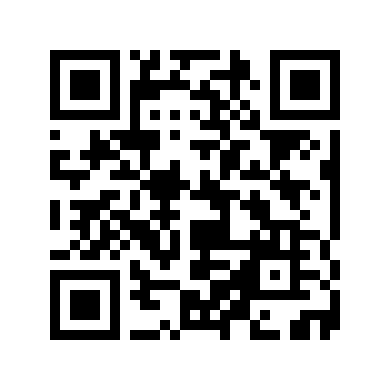

--- Product Safety Information: DAL-001 ---


,0
product_id,DAL-001
name,Organic Tomato Sauce
origin,"Parma, Italy"
safety_status,Certified Organic
allergens,None
expiry,2025-12-01
traceability_url,https://dalgiardino.com/mobile_demo/app4/app4_...



QR Code for: DAL-002


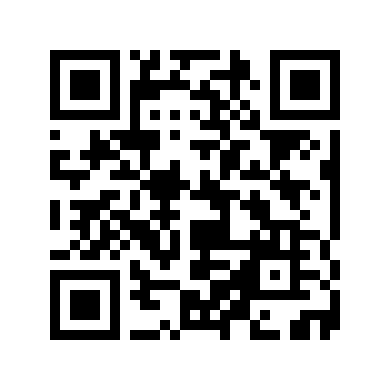

--- Product Safety Information: DAL-002 ---


,1
product_id,DAL-002
name,Extra Virgin Olive Oil
origin,"Tuscany, Italy"
safety_status,DOP Certified
allergens,None
expiry,2026-06-15
traceability_url,https://dalgiardino.com/mobile_demo/app4/app4_...


In [5]:
import qrcode
import pandas as pd
from IPython.display import display, Image
import os

class FoodSafetySystem:
    def __init__(self):
        # Simulated database based on the structure of the provided example
        self.db = pd.DataFrame([
            {
                'product_id': 'DAL-001',
                'name': 'Organic Tomato Sauce',
                'origin': 'Parma, Italy',
                'safety_status': 'Certified Organic',
                'allergens': 'None',
                'expiry': '2025-12-01',
                'traceability_url': 'https://dalgiardino.com/mobile_demo/app4/app4_post_scan.html$0'
            },
            {
                'product_id': 'DAL-002',
                'name': 'Extra Virgin Olive Oil',
                'origin': 'Tuscany, Italy',
                'safety_status': 'DOP Certified',
                'allergens': 'None',
                'expiry': '2026-06-15',
                'traceability_url': 'https://dalgiardino.com/mobile_demo/app4/app4_traceability.html$0'
            }
        ])

    def generate_qr(self, product_id):
        """Generates a QR code for a specific product ID."""
        product = self.db[self.db['product_id'] == product_id]
        if product.empty:
            return None

        # Points to the selected local dashboard file
        data = "file:///content/food_safety_dashboard.html"
        qr = qrcode.QRCode(version=1, box_size=10, border=5)
        qr.add_data(data)
        qr.make(fit=True)

        img = qr.make_image(fill_color="black", back_color="white")
        filename = f"{product_id}_qr.png"
        img.save(filename)
        return filename

    def generate_all_qrs(self):
        """Generates QR codes for all products in the database."""
        generated_files = []
        for pid in self.db['product_id']:
            fname = self.generate_qr(pid)
            if fname:
                generated_files.append(fname)
        return generated_files

    def scan_product(self, product_id):
        """Displays data associated with a product ID."""
        product = self.db[self.db['product_id'] == product_id]
        if product.empty:
            print(f"Error: Product {product_id} not found.")
        else:
            print(f"--- Product Safety Information: {product_id} ---")
            display(product.T)

# Initialize the model
safety_model = FoodSafetySystem()

# Generate QR codes for all products
all_qrs = safety_model.generate_all_qrs()
print(f"Generated {len(all_qrs)} QR codes.")

# Display the generated QR codes and their info
for qr_path in all_qrs:
    current_product_id = qr_path.replace('_qr.png', '')
    display_qr_path = qr_path # Default to the generated path

    # The following block was causing the FileNotFoundError by trying to use
    # hardcoded paths that don't exist, instead of the generated QR code paths.
    # Removing it to ensure the generated QR code files are displayed.
    # if current_product_id == 'DAL-001':
    #     display_qr_path = '/content/fd8c370c-0b94-49dc-8f09-378adf85762b.png'
    # elif current_product_id == 'DAL-002':
    #     display_qr_path = '/content/ad5f027b-edbe-4036-b737-25df43c4829f.png'

    print(f"\nQR Code for: {current_product_id}")
    display(Image(filename=display_qr_path))
    safety_model.scan_product(current_product_id)

In [6]:
from IPython.display import HTML

# Open and display the food_safety_dashboard.html file
with open('/content/food_safety_dashboard.html', 'r') as f:
    html_content = f.read()

display(HTML(html_content))

In [7]:
import json
import time
import pandas as pd
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

with open("export_all_products.json", "r", encoding="utf-8") as f:
    enhanced_products = json.load(f)

if isinstance(enhanced_products, dict) and "products" in enhanced_products:
    enhanced_products = enhanced_products["products"]

def enhanced_normalize_product(record):
    product = record.get("product_identifier", {})
    safety = record.get("safety_and_quality_information", {})
    recall = record.get("recall_information", {})
    supply = record.get("supply_chain_information", {})
    metadata = record.get("record_metadata", {})

    return {
        "record_id": metadata.get("record_id", ""),
        "product_name": product.get("product_name", ""),
        "brand_name": product.get("brand_name", ""),
        "gtin": product.get("gtin", ""),
        "batch_id": product.get("batch_id", ""),
        "qr_code_id": product.get("qr_code_id", ""),
        "category": product.get("food_category", ""),
        "origin": supply.get("origin_location", ""),
        "inspection_status": safety.get("inspection_status", ""),
        "inspection_date": safety.get("inspection_date", ""),
        "quality_score": safety.get("quality_score", ""),
        "temperature_status": safety.get("temperature_control_status", ""),
        "allergen_warning": safety.get("allergen_warning", ""),
        "recall_status": recall.get("recall_status", "Unknown"),
        "risk_level": recall.get("risk_level", "Unknown"),
        "recall_reason": recall.get("recall_reason", ""),
        "last_recall_check": recall.get("last_recall_check", ""),
        "expiration_date": product.get("expiration_date", ""),
        "last_updated": metadata.get("last_updated", ""),
        "source_system": metadata.get("source_system", ""),
        "raw_record": record
    }

def enhanced_parse_date(value):
    if not value:
        return None
    try:
        return pd.to_datetime(value, utc=True)
    except Exception:
        return None

def enhanced_is_expiring_soon(value, days=10):
    date = enhanced_parse_date(value)
    if date is None:
        return False
    now = pd.Timestamp.now(tz="UTC")
    difference = (date - now).days
    return 0 <= difference <= days

def enhanced_consumer_view(record):
    normalized = enhanced_normalize_product(record)

    return {
        "product_name": normalized["product_name"],
        "brand_name": normalized["brand_name"],
        "gtin": normalized["gtin"],
        "batch_id": normalized["batch_id"],
        "qr_code_id": normalized["qr_code_id"],
        "category": normalized["category"],
        "origin": normalized["origin"],
        "inspection_status": normalized["inspection_status"],
        "inspection_date": normalized["inspection_date"],
        "quality_score": normalized["quality_score"],
        "temperature_status": normalized["temperature_status"],
        "allergen_warning": normalized["allergen_warning"],
        "recall_status": normalized["recall_status"],
        "risk_level": normalized["risk_level"],
        "recall_reason": normalized["recall_reason"],
        "last_recall_check": normalized["last_recall_check"],
        "expiration_date": normalized["expiration_date"],
        "last_updated": normalized["last_updated"],
        "source_system": normalized["source_system"]
    }

def enhanced_quality_check(record):
    public = enhanced_consumer_view(record)

    required_fields = [
        "product_name",
        "batch_id",
        "qr_code_id",
        "category",
        "origin",
        "inspection_status",
        "recall_status",
        "risk_level",
        "expiration_date",
        "last_updated"
    ]

    missing = [field for field in required_fields if not public.get(field)]
    score = round((len(required_fields) - len(missing)) / len(required_fields) * 100, 1)

    return {
        "quality_score_percent": score,
        "missing_required_fields": missing,
        "portable_json_ready": len(missing) == 0
    }

def enhanced_status_badge(value, kind="general"):
    value_text = str(value).lower()

    if kind == "recall":
        if value_text in ["active", "yes", "recall"]:
            return "<span class='enhanced-badge enhanced-danger'>Active Recall</span>"
        if value_text in ["none", "no", "clear"]:
            return "<span class='enhanced-badge enhanced-success'>No Recall</span>"
        return "<span class='enhanced-badge enhanced-warning'>Recall Unknown</span>"

    if kind == "inspection":
        if value_text in ["passed", "pass", "certified organic"]:
            return "<span class='enhanced-badge enhanced-success'>Inspection Passed</span>"
        if value_text in ["failed", "fail"]:
            return "<span class='enhanced-badge enhanced-danger'>Inspection Failed</span>"
        return "<span class='enhanced-badge enhanced-warning'>Inspection Unknown</span>"

    if kind == "risk":
        if value_text in ["high", "critical"]:
            return "<span class='enhanced-badge enhanced-danger'>High Risk</span>"
        if value_text == "medium":
            return "<span class='enhanced-badge enhanced-warning'>Medium Risk</span>"
        if value_text == "low":
            return "<span class='enhanced-badge enhanced-success'>Low Risk</span>"
        return "<span class='enhanced-badge enhanced-warning'>Risk Unknown</span>"

    return f"<span class='enhanced-badge enhanced-warning'>{value}</span>"

enhanced_rows = [enhanced_normalize_product(p) for p in enhanced_products]
enhanced_df = pd.DataFrame(enhanced_rows)
enhanced_df["expiring_soon"] = enhanced_df["expiration_date"].apply(enhanced_is_expiring_soon)

enhanced_total_products = len(enhanced_df)
enhanced_active_recalls = enhanced_df["recall_status"].astype(str).str.lower().isin(["active", "yes", "recall"]).sum()
enhanced_passed_inspections = enhanced_df["inspection_status"].astype(str).str.lower().isin(["passed", "pass", "certified organic"]).sum()
enhanced_expiring_soon = enhanced_df["expiring_soon"].sum()

enhanced_style = """
<style>
enhanced-title,
.enhanced-subtitle,
.enhanced-metric-card,
.enhanced-metric-card *,
.enhanced-product-card,
.enhanced-product-card *,
.enhanced-info-table,
.enhanced-info-table *,
.enhanced-product-meta,
.enhanced-timeline,
.enhanced-timeline *,
.enhanced-good-notice,
.enhanced-good-notice *,
.enhanced-notice,
.enhanced-notice * {
    color: #111 !important;
}

.enhanced-product-card {
    background: #ffffff !important;
}

.enhanced-info-table td {
    color: #111 !important;
}

.enhanced-info-table td:first-child {
    color: #000 !important;
    font-weight: 700 !important;
}

.enhanced-good-notice {
    background: #e6f4ea !important;
    color: #111 !important;
}

.enhanced-notice {
    background: #fce8e6 !important;
    color: #111 !important;
}

pre {
    background: #f6f8fa !important;
    color: #111 !important;
    white-space: pre-wrap;
    word-wrap: break-word;
}
.enhanced-title {
    font-family: Arial, sans-serif;
    font-size: 30px;
    font-weight: 700;
    margin-top: 28px;
    margin-bottom: 4px;
}
.enhanced-subtitle {
    font-family: Arial, sans-serif;
    color: #000;
    margin-bottom: 18px;
    line-height: 1.5;
}
.enhanced-metric-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 14px;
    margin-bottom: 20px;
}
.enhanced-metric-card {
    border: 1px solid #ddd;
    border-radius: 14px;
    padding: 16px;
    background: #fafafa;
    font-family: Arial, sans-serif;
}
.enhanced-metric-label {
    color: #000;
    font-size: 13px;
}
.enhanced-metric-value {
    font-size: 30px;
    font-weight: 700;
    margin-top: 6px;
}
.enhanced-product-card {
    border: 1px solid #ddd;
    border-radius: 16px;
    padding: 18px;
    margin-top: 16px;
    background: white;
    font-family: Arial, sans-serif;
}
.enhanced-product-title {
    font-size: 24px;
    font-weight: 700;
    margin-bottom: 6px;
}
.enhanced-product-meta {
    color: #000;
    margin-bottom: 12px;
}
.enhanced-badge {
    padding: 5px 10px;
    border-radius: 999px;
    font-size: 12px;
    font-weight: 700;
    margin-right: 6px;
    display: inline-block;
}
.enhanced-success {
    background: #e6f4ea;
    color: #137333;
}
.enhanced-warning {
    background: #fff4e5;
    color: #b06000;
}
.enhanced-danger {
    background: #fce8e6;
    color: #c5221f;
}
.enhanced-info-table {
    width: 100%;
    border-collapse: collapse;
    margin-top: 14px;
}
.enhanced-info-table td {
    border-bottom: 1px solid #eee;
    padding: 8px;
    vertical-align: top;
}
.enhanced-info-table td:first-child {
    font-weight: 700;
    width: 220px;
    color: #333;
}
.enhanced-notice {
    border-left: 5px solid #c5221f;
    background: #fce8e6;
    padding: 12px;
    margin-top: 12px;
    border-radius: 8px;
}
.enhanced-good-notice {
    border-left: 5px solid #137333;
    background: #e6f4ea;
    padding: 12px;
    margin-top: 12px;
    border-radius: 8px;
}
.enhanced-timeline {
    margin-top: 12px;
    padding-left: 18px;
}
.enhanced-timeline li {
    margin-bottom: 8px;
}
pre {
    white-space: pre-wrap;
    word-wrap: break-word;
}
</style>
"""

display(HTML(enhanced_style))

display(HTML(f"""
<div class="enhanced-title">Enhanced Portable Food Safety Dashboard</div>
<div class="enhanced-subtitle">
This enhanced section keeps the original prototype while adding search, public/private access views,
recall warnings, supply-chain timeline, export functions, data quality testing, and performance testing.
</div>

<div class="enhanced-metric-grid">
    <div class="enhanced-metric-card">
        <div class="enhanced-metric-label">Total Products</div>
        <div class="enhanced-metric-value">{enhanced_total_products}</div>
    </div>
    <div class="enhanced-metric-card">
        <div class="enhanced-metric-label">Active Recalls</div>
        <div class="enhanced-metric-value">{enhanced_active_recalls}</div>
    </div>
    <div class="enhanced-metric-card">
        <div class="enhanced-metric-label">Inspections Passed</div>
        <div class="enhanced-metric-value">{enhanced_passed_inspections} / {enhanced_total_products}</div>
    </div>
    <div class="enhanced-metric-card">
        <div class="enhanced-metric-label">Expiring ≤ 10 Days</div>
        <div class="enhanced-metric-value">{enhanced_expiring_soon}</div>
    </div>
</div>
"""))

enhanced_search_box = widgets.Text(
    value="",
    placeholder="Search product name, batch ID, category, origin, recall status, or inspection status",
    description="Search:",
    layout=widgets.Layout(width="75%")
)

enhanced_role_dropdown = widgets.Dropdown(
    options=["Consumer View", "Regulator View"],
    value="Consumer View",
    description="Access:"
)

enhanced_product_dropdown = widgets.Dropdown(
    options=[(f"{row['product_name']} | {row['batch_id']}", i) for i, row in enhanced_df.iterrows()],
    description="Product:",
    layout=widgets.Layout(width="75%")
)

enhanced_output = widgets.Output()

def enhanced_render_product(index, role):
    row = enhanced_df.iloc[index]
    record = row["raw_record"]
    public = enhanced_consumer_view(record)
    qc = enhanced_quality_check(record)

    recall_status = str(public["recall_status"]).lower()

    if recall_status in ["active", "yes", "recall"]:
        recall_message = f"""
        <div class="enhanced-notice">
            <strong>Warning:</strong> This product has an active recall status.
            Consumers should avoid using this product until official guidance is reviewed.
            <br><strong>Recall Reason:</strong> {public["recall_reason"] or "No reason provided."}
        </div>
        """
    else:
        recall_message = """
        <div class="enhanced-good-notice">
            <strong>Status:</strong> No active recall is currently listed for this product record.
        </div>
        """

    html = f"""
    <div class="enhanced-product-card">
        <div class="enhanced-product-title">{public["product_name"]}</div>
        <div class="enhanced-product-meta">
            Brand: {public["brand_name"] or "N/A"} |
            Batch: {public["batch_id"] or "N/A"} |
            QR ID: {public["qr_code_id"] or "N/A"}
        </div>

        {enhanced_status_badge(public["inspection_status"], "inspection")}
        {enhanced_status_badge(public["recall_status"], "recall")}
        {enhanced_status_badge(public["risk_level"], "risk")}

        {recall_message}

        <table class="enhanced-info-table">
            <tr><td>Category</td><td>{public["category"] or "N/A"}</td></tr>
            <tr><td>Origin</td><td>{public["origin"] or "N/A"}</td></tr>
            <tr><td>GTIN</td><td>{public["gtin"] or "N/A"}</td></tr>
            <tr><td>Inspection Status</td><td>{public["inspection_status"] or "N/A"}</td></tr>
            <tr><td>Inspection Date</td><td>{public["inspection_date"] or "N/A"}</td></tr>
            <tr><td>Temperature Status</td><td>{public["temperature_status"] or "N/A"}</td></tr>
            <tr><td>Quality Score</td><td>{public["quality_score"] or "N/A"}</td></tr>
            <tr><td>Allergen Warning</td><td>{public["allergen_warning"] or "N/A"}</td></tr>
            <tr><td>Recall Status</td><td>{public["recall_status"] or "N/A"}</td></tr>
            <tr><td>Risk Level</td><td>{public["risk_level"] or "N/A"}</td></tr>
            <tr><td>Last Recall Check</td><td>{public["last_recall_check"] or "N/A"}</td></tr>
            <tr><td>Expiration Date</td><td>{public["expiration_date"] or "N/A"}</td></tr>
            <tr><td>Last Updated</td><td>{public["last_updated"] or "N/A"}</td></tr>
            <tr><td>Source System</td><td>{public["source_system"] or "N/A"}</td></tr>
            <tr><td>Data Quality Score</td><td>{qc["quality_score_percent"]}%</td></tr>
        </table>
    """

    steps = record.get("supply_chain_information", {}).get("processing_steps", [])

    if steps:
        html += "<h3>Supply Chain Timeline</h3><ol class='enhanced-timeline'>"
        for step in steps:
            html += f"""
            <li>
                <strong>{step.get("step_name", "Step")}</strong> —
                {step.get("location", "Unknown location")} —
                {step.get("step_date", "Unknown date")}
            </li>
            """
        html += "</ol>"

    if role == "Regulator View":
        html += """
        <h3>Regulator-Only Full JSON Record</h3>
        <p>This view includes restricted backend and security metadata for audit, verification, and system control.</p>
        """
        html += f"""
        <pre style='background:#f6f8fa;padding:12px;border-radius:10px;overflow:auto;'>
{json.dumps(record, indent=2, ensure_ascii=False)}
        </pre>
        """
    else:
        html += """
        <h3>Consumer Portable JSON View</h3>
        <p>This filtered view removes restricted backend metadata and exposes only consumer-relevant food safety information.</p>
        """
        html += f"""
        <pre style='background:#f6f8fa;padding:12px;border-radius:10px;overflow:auto;'>
{json.dumps(public, indent=2, ensure_ascii=False)}
        </pre>
        """

    html += "</div>"
    return html

def enhanced_refresh_dashboard(*args):
    query = enhanced_search_box.value.lower().strip()

    if query:
        filtered = enhanced_df[
            enhanced_df.apply(
                lambda row: query in " ".join([
                    str(row.get("product_name", "")),
                    str(row.get("brand_name", "")),
                    str(row.get("batch_id", "")),
                    str(row.get("category", "")),
                    str(row.get("origin", "")),
                    str(row.get("recall_status", "")),
                    str(row.get("inspection_status", ""))
                ]).lower(),
                axis=1
            )
        ]

        enhanced_product_dropdown.options = [
            (f"{row['product_name']} | {row['batch_id']}", i)
            for i, row in filtered.iterrows()
        ]
    else:
        enhanced_product_dropdown.options = [
            (f"{row['product_name']} | {row['batch_id']}", i)
            for i, row in enhanced_df.iterrows()
        ]

    with enhanced_output:
        clear_output()

        if len(enhanced_product_dropdown.options) == 0:
            display(HTML("<div class='enhanced-product-card'>No matching product found.</div>"))
        else:
            if enhanced_product_dropdown.value is None:
                enhanced_product_dropdown.value = enhanced_product_dropdown.options[0][1]
            index = enhanced_product_dropdown.value
            display(HTML(enhanced_render_product(index, enhanced_role_dropdown.value)))

def enhanced_export_consumer_files(button):
    consumer_records = [enhanced_consumer_view(record) for record in enhanced_products]

    with open("consumer_portable_food_safety_records.json", "w", encoding="utf-8") as f:
        json.dump(consumer_records, f, indent=2, ensure_ascii=False)

    pd.DataFrame(consumer_records).to_csv("consumer_portable_food_safety_records.csv", index=False)

    with enhanced_output:
        display(HTML("""
        <div class="enhanced-good-notice">
            <strong>Export complete:</strong>
            consumer_portable_food_safety_records.json and consumer_portable_food_safety_records.csv were created.
        </div>
        """))

enhanced_export_button = widgets.Button(
    description="Export Consumer JSON/CSV",
    button_style="success"
)

enhanced_export_button.on_click(enhanced_export_consumer_files)

enhanced_search_box.observe(enhanced_refresh_dashboard, names="value")
enhanced_product_dropdown.observe(enhanced_refresh_dashboard, names="value")
enhanced_role_dropdown.observe(enhanced_refresh_dashboard, names="value")

display(widgets.VBox([
    widgets.HBox([enhanced_search_box, enhanced_role_dropdown]),
    enhanced_product_dropdown,
    enhanced_export_button,
    enhanced_output
]))

enhanced_refresh_dashboard()

In [8]:
enhanced_quality_results = []

for product in enhanced_products:
    public = enhanced_consumer_view(product)
    result = enhanced_quality_check(product)

    enhanced_quality_results.append({
        "product_name": public["product_name"],
        "batch_id": public["batch_id"],
        "quality_score_percent": result["quality_score_percent"],
        "missing_required_fields": ", ".join(result["missing_required_fields"]) if result["missing_required_fields"] else "None",
        "portable_json_ready": result["portable_json_ready"]
    })

enhanced_quality_df = pd.DataFrame(enhanced_quality_results)

display(HTML("""
<div class="enhanced-product-card">
    <h3>Additional Data Quality Test</h3>
    <p>
    This test checks whether each product record contains the required fields for the information story:
    product identity, batch ID, QR code ID, category, origin, inspection status, recall status,
    risk level, expiration date, and last updated timestamp.
    </p>
</div>
"""))

display(enhanced_quality_df)

enhanced_quality_passed = enhanced_quality_df["portable_json_ready"].sum()
enhanced_quality_total = len(enhanced_quality_df)

display(HTML(f"""
<div class="enhanced-product-card">
    <h3>Quality Test Summary</h3>
    <p><strong>{enhanced_quality_passed} / {enhanced_quality_total}</strong> product records are ready for consumer-facing portable JSON access.</p>
</div>
"""))

,product_name,batch_id,quality_score_percent,missing_required_fields,portable_json_ready
0,Organic Chicken Breast,CH-BATCH-001,100.0,None,True
1,Packaged Spinach,SP-BATCH-002,100.0,None,True
2,Fresh Strawberries,ST-BATCH-003,100.0,None,True
3,Whole Milk,MK-BATCH-004,100.0,None,True


In [9]:
enhanced_start_time = time.time()

for _ in range(1000):
    for product in enhanced_products:
        enhanced_consumer_view(product)

enhanced_end_time = time.time()

enhanced_total_seconds = enhanced_end_time - enhanced_start_time
enhanced_average_lookup_time = enhanced_total_seconds / (1000 * len(enhanced_products))

enhanced_performance_df = pd.DataFrame([
    {
        "test_name": "Consumer View Lookup Performance",
        "records_tested": len(enhanced_products),
        "iterations": 1000,
        "total_seconds": round(enhanced_total_seconds, 4),
        "average_seconds_per_lookup": round(enhanced_average_lookup_time, 6),
        "performance_target": "Under 2 seconds per lookup",
        "target_met": enhanced_average_lookup_time < 2
    }
])

display(HTML("""
<div class="enhanced-product-card">
    <h3>Additional Performance Test</h3>
    <p>
    This test repeatedly generates the consumer-facing portable JSON view to estimate lookup performance.
    The prototype target is to keep each lookup under 2 seconds.
    </p>
</div>
"""))

display(enhanced_performance_df)

,test_name,records_tested,iterations,total_seconds,average_seconds_per_lookup,performance_target,target_met
0,Consumer View Lookup Performance,4,1000,0.0215,0.000005,Under 2 seconds per lookup,True
